In [82]:
def plot_changepoint(cenario, ref_metric, method, client, server, segment, cluster_mapping, threshold=0.95, slice_window=["", ""], metric=None):
    start = pd.to_datetime(slice_window[0]) if (len(slice_window) > 0 and slice_window[0]) else None
    end = pd.to_datetime(slice_window[1]) if (len(slice_window) > 1 and slice_window[1]) else None

    metric_val = metric if metric is not None else ref_metric
    file_name = f"{client}_{server}_{segment}.csv"
    
    df_serie = pd.read_csv(os.path.join('series', cenario, metric_val, file_name))
    df_serie['timestamp'] = pd.to_datetime(df_serie['timestamp'], format='%Y-%m-%d %H:%M:%S')
    val_col_name = df_serie.columns[1]

    path_suffix = f"_{threshold}" if method.startswith('vwcd') else ""
    cluster_path = os.path.join('clusters', cenario, method, f"clusters_K03_features_{method}_{ref_metric}{path_suffix}.csv")
    
    df_clusters = pd.read_csv(cluster_path)
    df_clusters['timestamp'] = pd.to_datetime(df_clusters['timestamp'], format='%Y-%m-%d %H:%M:%S')
    
    df_c = df_clusters[
        (df_clusters['client'] == client) & 
        (df_clusters['server'] == server) & 
        (df_clusters['block'] == segment)
    ].sort_values('timestamp')

    fig, ax1 = plt.subplots(figsize=(12, 5))
    
    # 1. Plotar a série inteira como "fundo" (contínua, cor preta/initial)
    ax1.plot(df_serie['timestamp'], df_serie[val_col_name], color='black', label='Início', linewidth=2, zorder=1)

    # 2. Sobrepor os segmentos coloridos
    for i in range(len(df_c)):
        start_time = df_c['timestamp'].iloc[i]
        next_time = df_c['timestamp'].iloc[i+1] if i < len(df_c)-1 else df_serie['timestamp'].max()
        cluster_id = df_c['cluster'].iloc[i]
        
        subset = df_serie[(df_serie['timestamp'] >= start_time) & (df_serie['timestamp'] <= next_time)]
        
        if not subset.empty:
            info = cluster_mapping.get(cluster_id, {'name': 'Unknown', 'color': 'black'})
            
            # Label condicional para não repetir na legenda
            lbl = info['name'] if info['name'] not in [l for l in ax1.get_legend_handles_labels()[1]] else None
            
            ax1.plot(subset['timestamp'], subset[val_col_name], color=info['color'], label=lbl, linewidth=2, zorder=2)
            
            # Plotar CP (apenas se estiver na janela)
            if (not start or start_time >= start) and (not end or start_time <= end):
                ax1.axvline(x=start_time, color='red', linestyle='--', linewidth=1, alpha=0.6, zorder=3)

    # 3. Cortes da janela (aplicar ao final)
    if start: ax1.set_xlim(left=start)
    if end: ax1.set_xlim(right=end)

    ax1.set_title(f'{method.upper()} - {client}/{server}/{segment}')
    ax1.set_ylabel(val_col_name.capitalize())
    ax1.set_xlabel('Time')
    
    ax1.legend(loc='best')
    fig.tight_layout()
    plt.show()
    plt.close("all")

In [88]:
cenario = 'NDT'
ref_metric = 'rtt_down'
method = 'vwcd_w24_fp2'
threshold = 0.95
cliente = 'Land'
server = 'RNP-MG'

cluster_mapping = {
    0: {'name': 'Melhora', 'color': 'forestgreen'},
    1: {'name': 'Estável', 'color': 'gray'},
    2: {'name': 'Piora',   'color': 'crimson'}
}

# ler o df_cluster
file_path = os.path.join('clusters', cenario, method, f"clusters_K03_features_{method}_{ref_metric}_{threshold}.csv")
df_clusters = pd.read_csv(file_path)

# filtrar para o cliente, servidor e segmento
df_c = df_clusters[(df_clusters['client'] == cliente) & (df_clusters['server'] == server)]

# printar cliente, servidor, segmento, timestamp e cluster
print(df_c[['timestamp', 'cluster', 'block']])

              timestamp  cluster block
65  2026-01-09 03:06:51        1   s01
66  2026-01-09 10:57:46        1   s01
67  2026-01-29 13:12:13        1   s01
68  2026-01-29 18:27:05        1   s01
69  2026-02-02 11:03:46        2   s01
70  2026-02-02 18:54:19        0   s01


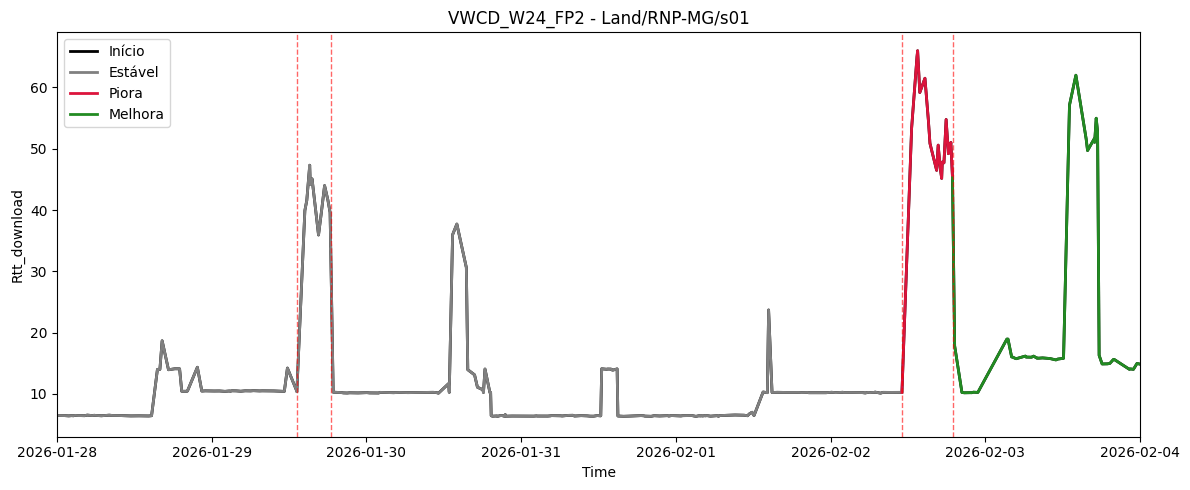

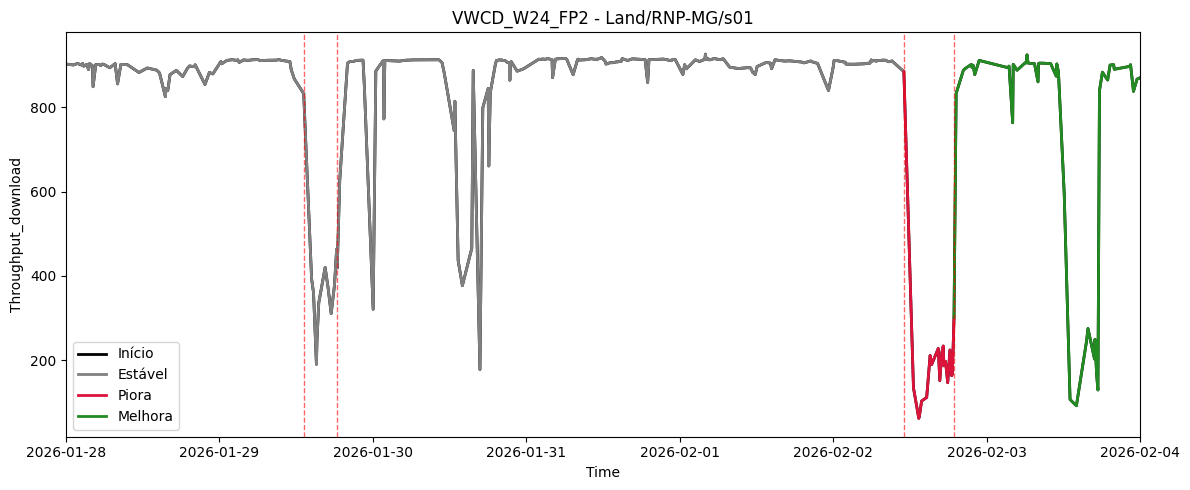

In [93]:
segment = 's01'
# slice_window = ["2026-01-08", "2026-01-15"]
slice_window = ["2026-01-28", "2026-02-04"]
# slice_window = ["", ""]
metric = 'rtt_down'
plot_changepoint(cenario, ref_metric, method, cliente, server, segment, cluster_mapping, threshold=threshold, metric=metric, slice_window=slice_window)
metric = 'tp_down'
plot_changepoint(cenario, ref_metric, method, cliente, server, segment, cluster_mapping, threshold=threshold, metric=metric, slice_window=slice_window)